In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [50]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score


In [5]:
df= pd.read_csv('Social_Network_Ads.csv')

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [8]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [9]:
if 'User ID' in df.columns:
    df=df.drop('User ID' , axis=1)

In [10]:
df['Gender']=df['Gender'].map({
    'Male':1,
    'Female':0
})

In [11]:
x=df.drop('Purchased' , axis=1)

In [12]:
y=df['Purchased']

In [13]:
x.head()

,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000


In [14]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [15]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [17]:
model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred=model.predict(x_test)

In [44]:
result = pd.DataFrame({
    "Actual" : y_test,
    "Pred" : y_pred})

In [45]:
result.head()

,Actual,Pred
209,0,0
280,1,1
33,0,0
210,1,1
93,0,0


In [46]:
cm =confusion_matrix(y_test,y_pred)
print(cm)

[[50  2]
 [ 7 21]]


In [47]:
i=model.intercept_

In [23]:
c=model.coef_

In [24]:
print(i)
print(c)

[-1.00504843]
[[0.13721002 1.98963144 1.14512193]]


Text(50.722222222222214, 0.5, 'Actual')

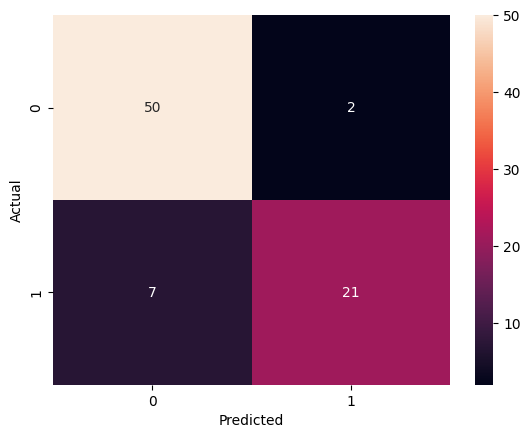

In [48]:
sns.heatmap(
    cm,
    annot=True,
)

plt.xlabel('Predicted')
plt.ylabel('Actual')



In [54]:
print("\nPREDICTED VALUES:\n")
print(y_pred)

print("\nACTUAL VALUES:\n")
print(y_test.values)


PREDICTED VALUES:

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]

ACTUAL VALUES:

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1]


In [27]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [28]:
print('TN : ',TN)
print('TP : ',TP)
print('FN : ',FN)
print('FP : ',FP)

TN :  50
TP :  21
FN :  7
FP :  2


In [29]:
accuracy= (TP+TN)/(TN+TP+FN+FP)
print(accuracy)

0.8875


In [30]:
error=1-accuracy
print(error)

0.11250000000000004


In [31]:
precision = TP/(TP+FP)
print(precision)

0.9130434782608695


In [32]:
recall = TP/(TP+FN)
print(recall)

0.75


In [33]:
a=accuracy_score(y_test,y_pred)
print(a)

0.8875


In [34]:
p=precision_score(y_test,y_pred)
print(p)

0.9130434782608695


In [35]:
r=recall_score(y_test,y_pred)

In [36]:
print(r)

0.75


In [37]:
example=[[1, 35, 60000]]
example_trans=scaler.transform(example)
example_pred=model.predict(example_trans)
if example_pred[0] == 1 :
    print("going to purh")
else:
    print("not")

not


C:\Users\varad\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
probability = model.predict_proba(example_trans)

In [39]:
print(probability)

[[0.85457876 0.14542124]]
